In [2]:
import pandas as pd

import kagglehub
path = kagglehub.dataset_download("parulpandey/palmer-archipelago-antarctica-penguin-data")

In [3]:
df = pd.read_csv(path + "/penguins_lter.csv")

In [4]:
print(df.head())
print(df.info())

  studyName  Sample Number                              Species  Region  \
0   PAL0708              1  Adelie Penguin (Pygoscelis adeliae)  Anvers   
1   PAL0708              2  Adelie Penguin (Pygoscelis adeliae)  Anvers   
2   PAL0708              3  Adelie Penguin (Pygoscelis adeliae)  Anvers   
3   PAL0708              4  Adelie Penguin (Pygoscelis adeliae)  Anvers   
4   PAL0708              5  Adelie Penguin (Pygoscelis adeliae)  Anvers   

      Island               Stage Individual ID Clutch Completion  Date Egg  \
0  Torgersen  Adult, 1 Egg Stage          N1A1               Yes  11/11/07   
1  Torgersen  Adult, 1 Egg Stage          N1A2               Yes  11/11/07   
2  Torgersen  Adult, 1 Egg Stage          N2A1               Yes  11/16/07   
3  Torgersen  Adult, 1 Egg Stage          N2A2               Yes  11/16/07   
4  Torgersen  Adult, 1 Egg Stage          N3A1               Yes  11/16/07   

   Culmen Length (mm)  Culmen Depth (mm)  Flipper Length (mm)  Body Mass (g)  \


In [10]:
df.drop(["studyName" , "Sample Number" , "Individual ID" , "Clutch Completion" , "Date Egg" , "Comments" , "Stage" ,"Region" ] , axis= 1 , inplace= True)

In [9]:
df["Stage"].value_counts()

,count
Stage,
"Adult, 1 Egg Stage",344


In [12]:
for i in df.columns :
  print(i , len(df[i].value_counts()) , df[i].dtype)

Species 3 object
Island 3 object
Culmen Length (mm) 164 float64
Culmen Depth (mm) 80 float64
Flipper Length (mm) 55 float64
Body Mass (g) 94 float64
Sex 3 object
Delta 15 N (o/oo) 330 float64
Delta 13 C (o/oo) 331 float64


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              344 non-null    object 
 1   Island               344 non-null    object 
 2   Culmen Length (mm)   342 non-null    float64
 3   Culmen Depth (mm)    342 non-null    float64
 4   Flipper Length (mm)  342 non-null    float64
 5   Body Mass (g)        342 non-null    float64
 6   Sex                  334 non-null    object 
 7   Delta 15 N (o/oo)    330 non-null    float64
 8   Delta 13 C (o/oo)    331 non-null    float64
dtypes: float64(6), object(3)
memory usage: 24.3+ KB


In [15]:
df.isnull().sum()

,0
Species,0
Island,0
Culmen Length (mm),2
Culmen Depth (mm),2
Flipper Length (mm),2
Body Mass (g),2
Sex,10
Delta 15 N (o/oo),14
Delta 13 C (o/oo),13


In [16]:
# Preprocessing
num_cols = [
    'Culmen Length (mm)',
    'Culmen Depth (mm)',
    'Flipper Length (mm)',
    'Body Mass (g)',
    'Delta 15 N (o/oo)',
    'Delta 13 C (o/oo)'
]

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


In [17]:
df["Sex"] = df["Sex"].fillna(df.Sex.mode()[0])

In [18]:
df.isnull().sum()

,0
Species,0
Island,0
Culmen Length (mm),0
Culmen Depth (mm),0
Flipper Length (mm),0
Body Mass (g),0
Sex,0
Delta 15 N (o/oo),0
Delta 13 C (o/oo),0


In [21]:
from  sklearn.preprocessing import LabelEncoder
le_Species  = LabelEncoder()
le_island = LabelEncoder()
le_Sex = LabelEncoder()

In [22]:
x = df.drop("Species" , axis= 1)
y = df["Species"]

In [24]:
x["Island"] = le_island.fit_transform(x["Island"])
x["Sex"] = le_Sex.fit_transform(x["Sex"])
y = le_Species.fit_transform(y)

In [35]:
x.head()


,Island,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,2,39.10000,18.70000,181.000000,3750.000000,2,8.733382,-25.686292
1,2,39.50000,17.40000,186.000000,3800.000000,1,8.949560,-24.694540
2,2,40.30000,18.00000,195.000000,3250.000000,1,8.368210,-25.333020
3,2,43.92193,17.15117,200.915205,4201.754386,2,8.733382,-25.686292
4,2,36.70000,19.30000,193.000000,3450.000000,1,8.766510,-25.324260


In [36]:
y[:300]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x , y , test_size=.2 , random_state= 10 , shuffle= True  )

In [42]:
#  Training model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion= 'entropy' , max_depth= 5 )
model.fit(X_train , y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [43]:
# Evaluation
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

1.0
0.9420289855072463


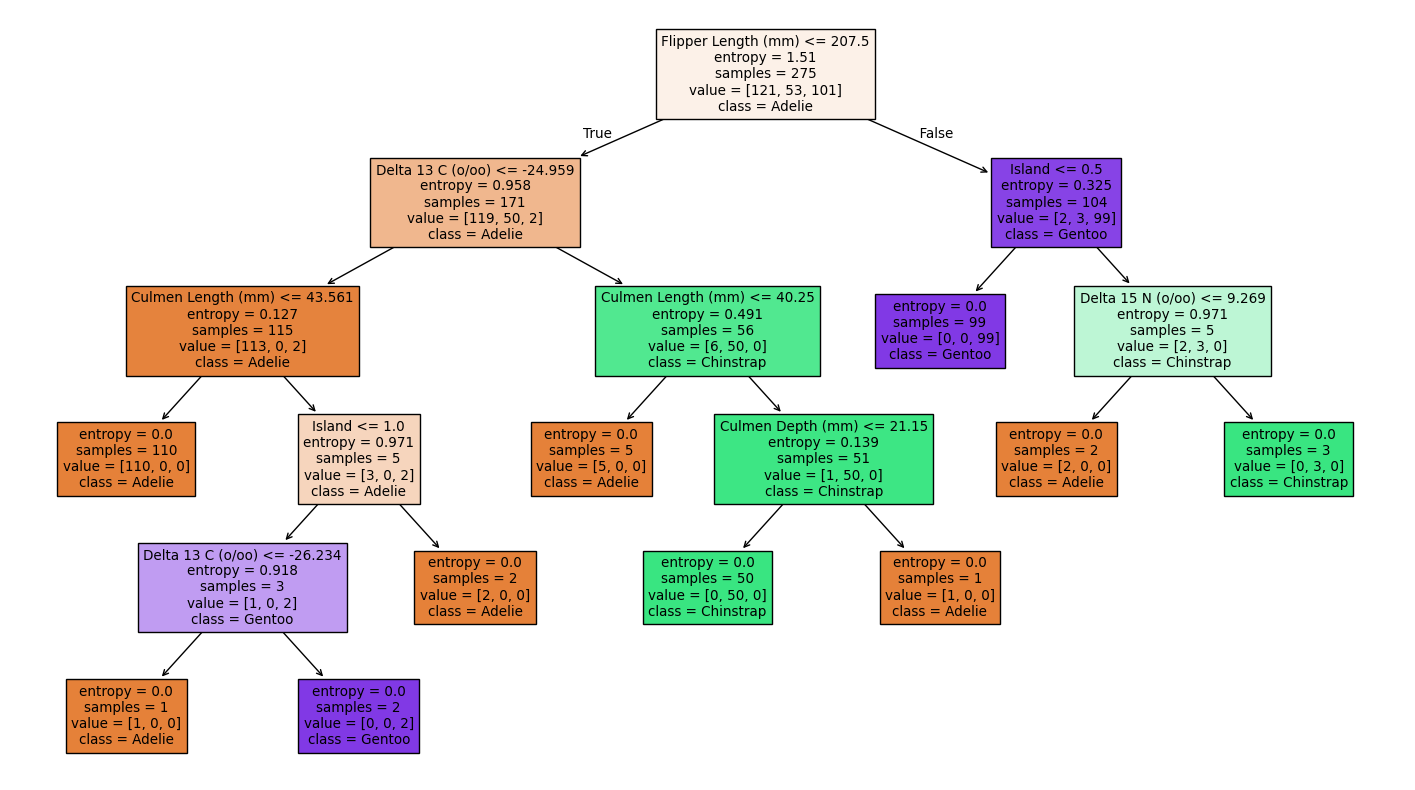

In [46]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize = (18 , 10))
plot_tree(model ,  feature_names=X_train.columns,class_names=['Adelie', 'Chinstrap', 'Gentoo'],filled=True)
plt.show()

In [47]:
importance = pd.DataFrame({'feature':X_train.columns,'importance':model.feature_importances_}).sort_values('importance',ascending=False)
print("importance Feature is :- \n" , importance )

importance Feature is :- 
                feature  importance
3  Flipper Length (mm)    0.524135
7    Delta 13 C (o/oo)    0.299813
0               Island    0.074741
1   Culmen Length (mm)    0.072513
2    Culmen Depth (mm)    0.017104
6    Delta 15 N (o/oo)    0.011694
5                  Sex    0.000000
4        Body Mass (g)    0.000000


In [49]:
from sklearn.metrics import confusion_matrix , classification_report
y_pred = model.predict(X_test)
print(confusion_matrix(y_test , y_pred))
print(classification_report(y_test , y_pred))

[[30  1  0]
 [ 1 12  2]
 [ 0  0 23]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        31
           1       0.92      0.80      0.86        15
           2       0.92      1.00      0.96        23

    accuracy                           0.94        69
   macro avg       0.94      0.92      0.93        69
weighted avg       0.94      0.94      0.94        69



In [52]:
from sklearn.ensemble import RandomForestClassifier
model0 =  RandomForestClassifier(n_estimators= 100 , criterion= 'entropy' , max_depth= 5 )
model0.fit(X_train , y_train)




RandomForestClassifier(criterion='entropy', max_depth=5)

In [53]:
# Evaluation
print(model0.score(X_train,y_train))
print(model0.score(X_test,y_test))


1.0
0.9710144927536232


In [55]:
y_pred0  = model0.predict(X_test)
print(confusion_matrix(y_test , y_pred0))
print(classification_report(y_test , y_pred0))

[[30  1  0]
 [ 1 14  0]
 [ 0  0 23]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        31
           1       0.93      0.93      0.93        15
           2       1.00      1.00      1.00        23

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69

